### 1º Trabalho Prático - ANADI
#### Turma 3DH Grupo 8: 
##### Mariana Martins 1230679
##### Luna Gomes 1231651
##### Samara Miranda 1230432

### 1. Importação de Bibliotecas e Dados

In [1]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels plotly streamlit openpyxl

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 5.3 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 6.7 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.1 MB 7.5 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 7.2 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.8 MB/s  0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


### 2. Visualização Inicial dos Datasets

In [2]:
import pandas as pd
import numpy as np

# 1. Carregar os dados
# O parâmetro na_values converte automaticamente "N/D" em valores nulos (NaN)
df_ip = pd.read_excel('IP_data.xlsx', na_values='N/D')
df_pt = pd.read_excel('PTD_data.xlsx', na_values='N/D')

# 2. Ver as primeiras linhas e os tipos de dados
print("--- INFO IP DATA ---")
print(df_ip.info())
print("\n--- INFO PTD DATA ---")
print(df_pt.info())

# Visualizar as primeiras 5 linhas de cada um para confirmar a leitura
display(df_ip.head())
display(df_pt.head())

--- INFO IP DATA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9300 entries, 0 to 9299
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ano                           9300 non-null   int64  
 1   Mês                           9300 non-null   int64  
 2   Distrito                      9300 non-null   object 
 3   Concelho                      9300 non-null   object 
 4   Freguesia                     9300 non-null   object 
 5   Tipo de Lâmpada               9300 non-null   object 
 6   Luminárias                    9299 non-null   float64
 7   Lâmpadas por Luminária        9258 non-null   float64
 8   Lâmpadas                      9258 non-null   float64
 9   Potência Instalada Total (W)  8483 non-null   float64
 10  CodDistrito                   9300 non-null   int64  
 11  CodDistritoConcelho           9300 non-null   int64  
 12  coddistritoconcelhofreguesia  9300 non-nu

,Ano,Mês,Distrito,Concelho,Freguesia,Tipo de Lâmpada,Luminárias,Lâmpadas por Luminária,Lâmpadas,Potência Instalada Total (W),CodDistrito,CodDistritoConcelho,coddistritoconcelhofreguesia
0,2026,2,Leiria,Alvaiázere,Almoster,LED,716.0,715.0,715.0,29010.800171,10,1002,100201
1,2026,2,Leiria,Alvaiázere,Almoster,Outros/Não definido,23.0,23.0,23.0,225.000000,10,1002,100201
2,2026,2,Leiria,Alvaiázere,Almoster,Sódio,27.0,26.0,26.0,1890.000000,10,1002,100201
3,2026,2,Leiria,Alvaiázere,Pelmá,Mercúrio,1.0,1.0,1.0,50.000000,10,1002,100205
4,2026,2,Leiria,Alvaiázere,Alvaiázere,Mercúrio,3.0,3.0,3.0,150.000000,10,1002,100208


,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Nível de Utilização [%],Tipo Construtivo,Potência Contratada [kVA],Número de Clientes,Potência Geração [kW],Número de Clientes Produtores,CodDistritoConcelho,Concelho
0,1307D2012500,"41.1849010463209, -8.14785254356171",400,60%-79%,Cabine pré-fabricada,1052.69,131,NaN,<20,1307,Marco de Canaveses
1,1307D2012900,"41.0869934226954, -8.24673374651495",250,60%-79%,Cabine baixa integrada em edifício,775.20,115,NaN,<20,1307,Marco de Canaveses
2,1307D2013100,"41.1129221154249, -8.21276525945275",250,60%-79%,Cabine alta,1104.19,176,NaN,<20,1307,Marco de Canaveses
3,1307D2013800,"41.1329530486552, -8.13563404382479",50,+100%,Aéreo - AS,238.07,36,NaN,<20,1307,Marco de Canaveses
4,1307D2015100,"41.1228444565974, -8.11290068900831",250,0%-19%,Aéreo - AI,608.51,94,NaN,<20,1307,Marco de Canaveses


### 3. Manipulação de Dados (ETL)

#### Processamento da Iluminação Pública (IP_data)
 Preparamos os dados da Iluminação Pública (IP) para serem integrados com os dados dos Postos de Transformação (PTD). O objetivo é converter a potência de Watts para kiloWatts (para manter a consistência de unidades) e isolar a potência proveniente de fontes ineficientes (Sódio e Mercúrio), que será a base para o cálculo do rácio de ineficiência tecnológica ($\beta_3$).

In [3]:
# 1. Criar variável binária Is_Ineficiente
# 1 se for Sódio ou Mercúrio, 0 para outros
df_ip['Is_Ineficiente'] = df_ip['Tipo de Lâmpada'].apply(lambda x: 1 if x in ['Sódio', 'Mercúrio'] else 0)

# 2. Criar variável Potência kW
df_ip['Potencia_kW'] = df_ip['Potência Instalada Total (W)'] / 1000

# 3. Agrupar por Distrito e Concelho 
df_ip_grouped = df_ip.groupby(['CodDistrito', 'Concelho','CodDistritoConcelho']).agg(
    P_IP_Total=('Potencia_kW', 'sum'),        # [cite: 114]
    P_IP_Inef=('Potencia_kW', lambda x: x[df_ip.loc[x.index, 'Is_Ineficiente'] == 1].sum())
).reset_index()

#### Processamento dos Postos de Transformação (PTD_data)

 Para converter o 'Nível de Utilização [%]' numa variável numérica contínua ($Y$), adotamos uma abordagem conservadora (pior cenário). Ao extrair o limite superior de cada intervalo (ex: de '60%-79%' extraímos 0.79), garantimos que a análise de viabilidade da rede considera a carga máxima esperada, minimizando riscos de sobrecarga na instalação de novos carregadores de VE.

In [4]:
# 1. Converter 'Nível de Utilização [%]' para decimal (ex: '60%-79%' -> 0.79)
# Nota: O enunciado sugere usar o limite superior do intervalo
def convert_utilizacao(valor):
    if isinstance(valor, str) and '%' in valor:
        # Extrai o segundo número se houver um intervalo, ou apenas o número
        import re
        nums = re.findall(r'\d+', valor)
        if nums:
            return float(nums[-1]) / 100
    return np.nan

df_pt['Util_Decimal'] = df_pt['Nível de Utilização [%]'].apply(convert_utilizacao)

# 2. Agrupar por Distrito e Concelho
df_pt_grouped = df_pt.groupby(['CodDistritoConcelho']).agg(
    Cap_PTD=('Potência instalada [kVA]', 'sum'), # [cite: 119]
    Util_Media=('Util_Decimal', 'mean'),         # [cite: 120]
    N_PTDs=('Concelho', 'count')                 # [cite: 121]
).reset_index()

#### Criação do Dataset Consolidado

Nesta etapa, realizamos o Merge dos datasets para obter uma visão consolidada por concelho. Implementamos as métricas de engenharia para calcular a folga de potência real, considerando:

> 1. Eficiência Energética: Ganho esperado com a transição para LED.

> 2. Segurança da Rede: Margem de exploração técnica de 92%.

> 3. Carga Nova (VE): Projeção de consumo para carregadores de 22kW com fator de simultaneidade.

In [5]:
# Unir os datasets
df_final = pd.merge(df_ip_grouped, df_pt_grouped, on='CodDistritoConcelho', how='inner')

# Cálculo das métricas solicitadas:
df_final['Delta_P_LED'] = df_final['P_IP_Inef'] * 0.65

# Folga Rede (com margem de segurança de 92%)
df_final['P_Folga'] = (df_final['Cap_PTD'] * 0.92) * (1 - df_final['Util_Media'])

# Carga VE (carregadores de 22 kW com fator de simultaneidade de 0.60)
df_final['P_VE'] = df_final['N_PTDs'] * 22 * 0.60

# Saldo Final de Viabilidade (D)
df_final['D'] = df_final['P_Folga'] + df_final['Delta_P_LED'] - df_final['P_VE']

# Rate Ineficiencia
df_final['Rate_Ineficiencia'] = df_final['P_IP_Inef'] / df_final['P_IP_Total']

# Ver dataset final
display(df_final.head())

,CodDistrito,Concelho,CodDistritoConcelho,P_IP_Total,P_IP_Inef,Cap_PTD,Util_Media,N_PTDs,Delta_P_LED,P_Folga,P_VE,D,Rate_Ineficiencia
0,1,Albergaria-a-Velha,102,451.711801,28.020,54540,0.469948,194,18.21300,26596.303834,2560.8,24053.716834,0.062031
1,1,Anadia,103,657.071801,73.545,55628,0.543009,223,47.80425,23387.762452,2943.6,20491.966702,0.111928
2,1,Arouca,104,585.974400,115.720,41884,0.527387,236,75.21800,18211.314133,3115.2,15171.332133,0.197483
3,1,Aveiro,105,1055.192001,144.420,197485,0.475475,509,93.87300,95298.999935,6718.8,88674.072935,0.136866
4,1,Castelo de Paiva,106,391.710100,137.900,25760,0.543228,128,89.63500,10825.122772,1689.6,9225.157772,0.352046


##### Processamento de Iluminação Pública (IP):
>Foi criada a variável binária Is_Ineficiente (1 para lâmpadas de Sódio/Mercúrio) e a potência foi convertida para kW. Os dados foram agregados por concelho para obter a potência total (P_IP_Total) e a potência ineficiente (P_IP_Inef).
##### Processamento dos Postos de Transformação (PTD):
>O 'Nível de Utilização [%]' foi normalizado para valores decimais (ex: 0.79). Agregaram-se os dados por concelho para calcular a capacidade instalada (Cap_PTD), utilização média (Util_Media) e o número de postos (N_PTDs).
##### Consolidação e Novas Variáveis:
> Os datasets foram fundidos via CodDistritoConcelho, permitindo o cálculo das métricas de viabilidade:
>* Ganho LED ($\Delta P_{LED}$): Potência libertada pela substituição tecnológica ($P_{IP\_Inef} \times 0.65$).
>* Folga Rede ($P_{Folga}$): Capacidade disponível considerando uma margem de segurança de 92%.Carga VE ($P_{VE}$):
>* Estimativa de carga para novos carregadores de 22 kW.
>* Saldo Final (D): Indicador de viabilidade técnica do projeto ($P_{Folga} + \Delta P_{LED} - P_{VE}$).
>* Rate Ineficiência: Rácio que mede o peso da tecnologia obsoleta no concelho.

### 4. Análise e Exploração de Dados

#### Mix Tecnológico e Concentração de Potência

Nesta fase, recorremos a bibliotecas de visualização (Matplotlib e Seaborn) para expor dois pontos críticos:

> 1. Mix Tecnológico Nacional: A proporção de carga que ainda depende de tecnologias obsoletas (Sódio/Mercúrio), o que representa o potencial de poupança.

> 2. Priorização Geográfica: Identificação dos 10 concelhos com maior 'potência ineficiente', sinalizando onde a substituição por LED teria um impacto imediato e massivo na libertação de carga para a rede elétrica.

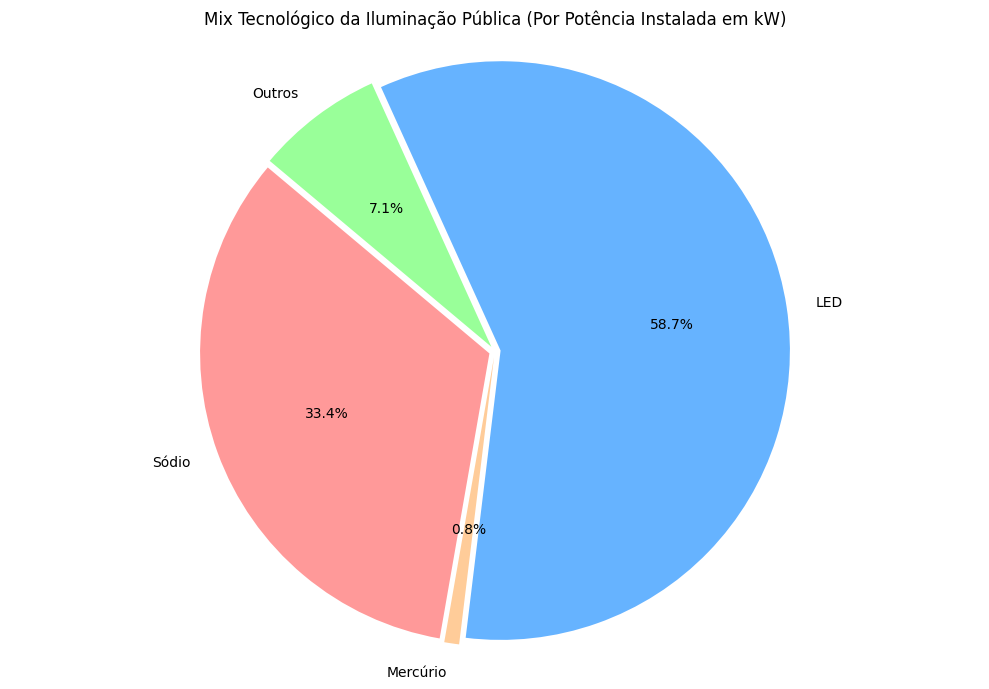

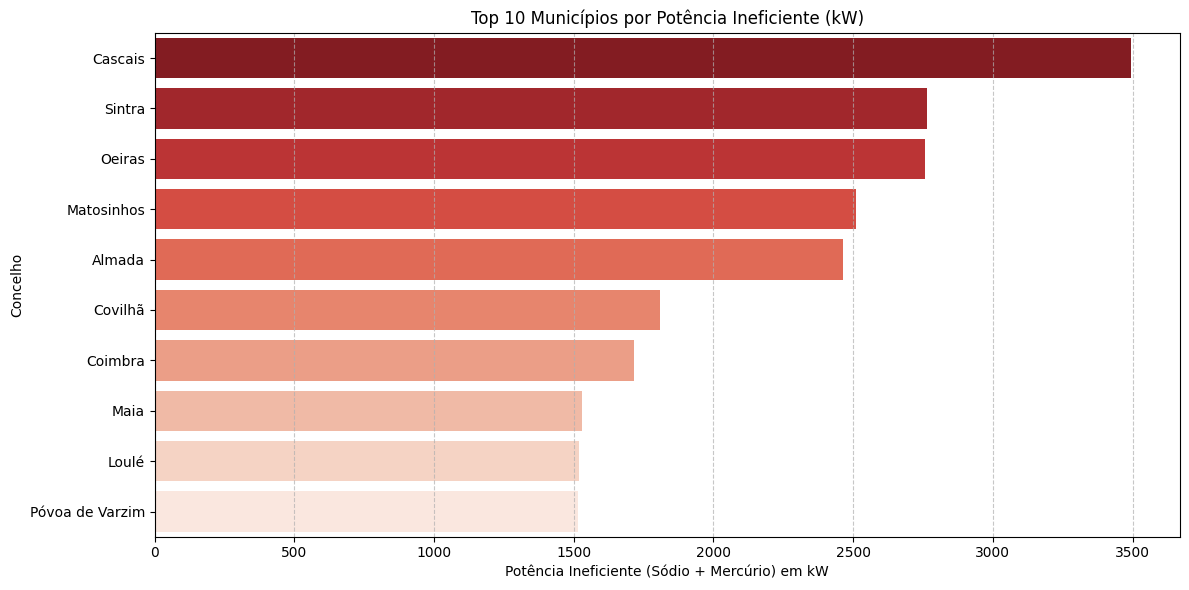

--- Resumo do Mix Tecnológico ---
Sódio: 60216.17 kW
Mercúrio: 1492.49 kW
LED: 105971.19 kW
Outros: 12828.02 kW


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Preparar dados detalhados para o Mix Tecnológico (df_ip original)
# Criamos uma cópia para não alterar o dataset original
df_ip_plot = df_ip.copy()

# Mapeamento das categorias
def mapear_categoria(tipo):
    if tipo in ['Sódio', 'Mercúrio', 'LED']:
        return tipo
    return 'Outros'

df_ip_plot['Categoria_Grafico'] = df_ip_plot['Tipo de Lâmpada'].apply(mapear_categoria)

# Agrupado pela nova categoria e adicionamos a potência
mix_data = df_ip_plot.groupby('Categoria_Grafico')['Potência Instalada Total (W)'].sum().reset_index()

# Converter para kW
mix_data['Potencia_kW'] = mix_data['Potência Instalada Total (W)'] / 1000

# Ordenar para garantir consistência no gráfico
ordem_manual = {'Sódio': 0, 'Mercúrio': 1, 'LED': 2, 'Outros': 3}
mix_data['Ordem'] = mix_data['Categoria_Grafico'].map(ordem_manual)
mix_data = mix_data.sort_values('Ordem')

# Cores para cada tecnologia
colors_map = {
    'Sódio': '#ff9999',    # Vermelho claro
    'Mercúrio': '#ffcc99', # Laranja claro
    'LED': '#66b3ff',      # Azul
    'Outros': '#99ff99'    # Verde claro
}
plot_colors = [colors_map.get(label) for label in mix_data['Categoria_Grafico']]

# Criar o Gráfico Detalhado
plt.figure(figsize=(10, 7))
plt.pie(
    mix_data['Potencia_kW'], 
    labels=mix_data['Categoria_Grafico'], 
    autopct='%1.1f%%', 
    colors=plot_colors, 
    startangle=140, 
    explode=[0.02] * len(mix_data), 
    shadow=False
)

plt.title('Mix Tecnológico da Iluminação Pública (Por Potência Instalada em kW)')
plt.axis('equal') 
plt.tight_layout()
plt.show()

# 2. Análise de Concentração (Municípios com mais potência ineficiente)
top_municipios = df_final.sort_values('P_IP_Inef', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='P_IP_Inef', 
    y='Concelho', 
    data=top_municipios, 
    hue='Concelho', 
    palette='Reds_r', 
    legend=False
)

plt.title('Top 10 Municípios por Potência Ineficiente (kW)')
plt.xlabel('Potência Ineficiente (Sódio + Mercúrio) em kW')
plt.ylabel('Concelho')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- Resumo do Mix Tecnológico ---")
for index, row in mix_data.iterrows():
    print(f"{row['Categoria_Grafico']}: {row['Potencia_kW']:.2f} kW")
    

#### Distribuição por Distrito (Boxplots)

Para entender a pressão sobre a rede elétrica, selecionámos os quatro distritos com maior densidade populacional e industrial (Aveiro, Lisboa, Porto e Setúbal). O uso de Boxplots é superior a simples médias, pois permite visualizar a dispersão dos dados, identificar concelhos com utilização atípica (outliers) e comparar a simetria da carga de rede entre diferentes regiões geográficas.

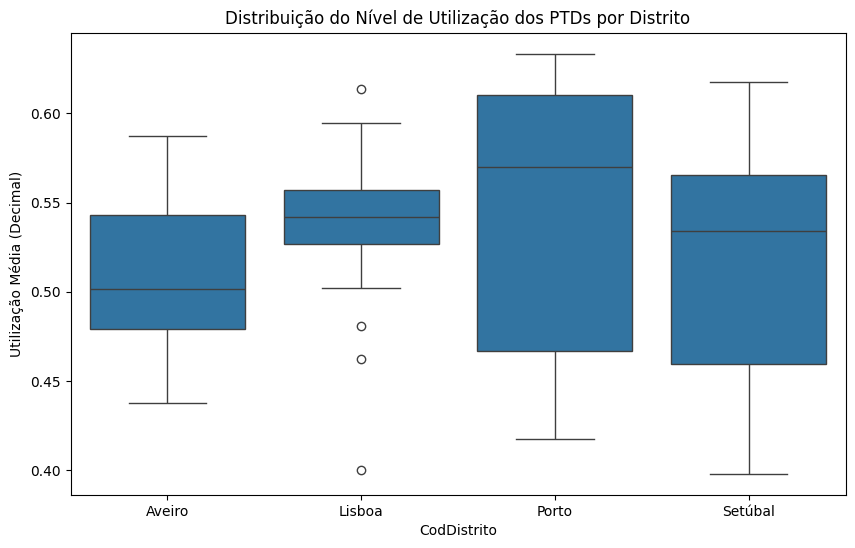

In [7]:
# Filtrar apenas os distritos solicitados
distritos_alvo = [1, 11, 13, 15] # Aveiro, Lisboa, Porto, Setúbal
df_boxplot = df_final[df_final['CodDistrito'].isin(distritos_alvo)]

plt.figure(figsize=(10, 6))
sns.boxplot(x='CodDistrito', y='Util_Media', data=df_boxplot)
plt.title('Distribuição do Nível de Utilização dos PTDs por Distrito')
plt.xticks([0, 1, 2, 3], ['Aveiro', 'Lisboa', 'Porto', 'Setúbal'])
plt.ylabel('Utilização Média (Decimal)')
plt.show()

#### Valores Omissos e Outliers

Antes de avançar para a modelação, é imperativo auditar a qualidade da variável dependente ($Y$). Identificamos 'ruído' nos dados sob a forma de valores omissos (NaN) e valores indeterminados (como '0%-19%' ou 'N/D'), que não fornecem uma leitura precisa da carga. Esta análise justifica a necessidade de limpeza ou imputação para evitar enviesamentos nas conclusões estatísticas.

In [8]:
# 1. Valores Omissos (NaN)
valores_omissos = df_pt['Nível de Utilização [%]'].isna().sum()

# 2. Valores Indeterminados (<20), no dataset: 0%-19%
mascara_indeterminados = df_pt['Nível de Utilização [%]'].astype(str).str.contains('0%-19%|N/D', case=False, na=False)
valores_indeterminados = mascara_indeterminados.sum()

total_falhas = valores_omissos + valores_indeterminados
total_registos = len(df_pt)
percentagem = (total_falhas / total_registos) * 100

print(f"Valores omissos (NaN): {valores_omissos}")
print(f"Valores indeterminados (<20 ou N/D): {valores_indeterminados}")
print(f"Prevalência total: {total_falhas} registos ({percentagem:.2f}% do total de PTDs).")

Valores omissos (NaN): 3064
Valores indeterminados (<20 ou N/D): 14338
Prevalência total: 17402 registos (24.16% do total de PTDs).


#### Identificação de Outliers

Antes de qualquer modelação, realizamos uma Análise Univariada do Nível de Utilização para identificar comportamentos atípicos (outliers). O uso do boxplot é estratégico para detetar PTDs que já se encontram em sobrecarga (acima do limite de 1.0 ou 100%). Identificar estes pontos é crucial, pois um concelho com muitos outliers positivos (acima da caixa) pode representar um risco elevado para a instalação de novos carregadores de 22 kW, mesmo que a sua média pareça favorável.

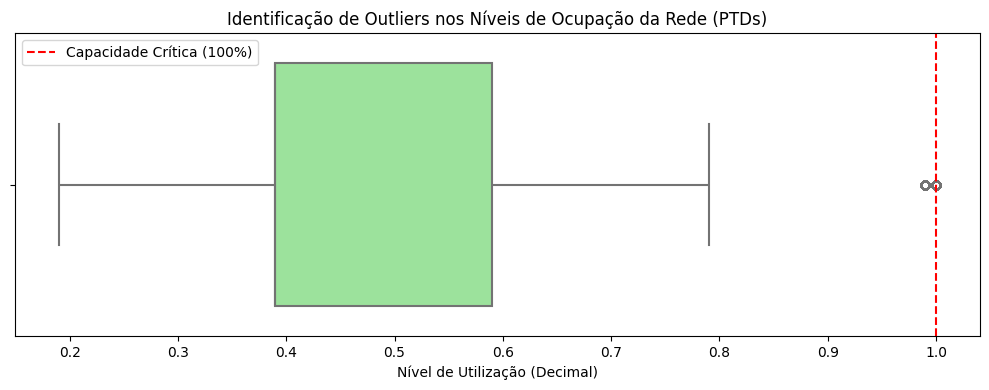

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

# Criar o Boxplot com a coluna decimal
sns.boxplot(x=df_pt['Util_Decimal'], color='lightgreen', fliersize=6, linewidth=1.5)

# títulos e rótulos
plt.title('Identificação de Outliers nos Níveis de Ocupação da Rede (PTDs)')
plt.xlabel('Nível de Utilização (Decimal)')

# Linha vermelha para destacar o limite crítico de 100% 
plt.axvline(x=1.0, color='red', linestyle='--', label='Capacidade Crítica (100%)')
plt.legend()

plt.tight_layout()
plt.show()

Através da análise do diagrama de extremos e quartis (Boxplot) representativo do nível de ocupação da rede, observa-se que 50% dos Postos de Transformação operam confortavelmente entre os 38% e 58% da sua capacidade. No entanto, o gráfico evidencia a presença de outliers críticos no extremo superior da distribuição. A concentração de valores atípicos junto e acima da linha de capacidade máxima (100%) revela a existência de infraestruturas em sobrecarga. Estes postos constituem estrangulamentos na rede, onde a instalação de postos de carregamento para mobilidade elétrica é tecnicamente inviável sem prévia intervenção de expansão de capacidade.

#### Estatística Descritiva (Municípios Específicos)

Para uma análise comparativa aprofundada, selecionámos quatro polos regionais (Coimbra, Évora, Braga e Faro). Nesta etapa, calculamos as Medidas de Localização (Média, Quartis e Mediana) e as Medidas de Dispersão e Forma (Desvio Padrão, Assimetria e Curtose). Esta caracterização permite identificar se a carga nestes concelhos segue uma distribuição normal ou se existem desequilíbrios locais (concentração de PTs sobrecarregados) que a média, isoladamente, não conseguiria revelar.

In [10]:
# Lista de concelhos pretendida
concelhos_foco = ['Coimbra', 'Évora', 'Braga', 'Faro']

# 1. Filtramos o dataset original (df_pt) que contém os dados de CADA posto individual
df_pt_foco = df_pt[df_pt['Concelho'].isin(concelhos_foco)]

# 2. Calculamos as estatísticas sobre a distribuição de todos os postos de cada concelho
resumo_estatistico = df_pt_foco.groupby('Concelho')['Util_Decimal'].agg([
    'mean',                     # Média
    'std',                      # Desvio Padrão
    lambda x: x.quantile(0.25), # Q1 (1º Quartil)
    'median',                   # Mediana (Q2)
    lambda x: x.quantile(0.75), # Q3 (3º Quartil)
    'skew',                     # Assimetria
    lambda x: x.kurtosis()      # Curtose
]).reset_index()

# 3. Nomear colunas
resumo_estatistico.columns = ['Concelho', 'Média', 'Desvio Padrão', 'Q1', 'Mediana', 'Q3', 'Assimetria', 'Curtose']

# 4. Apresentar com as 4 casas decimais
display(resumo_estatistico.round(4))

,Concelho,Média,Desvio Padrão,Q1,Mediana,Q3,Assimetria,Curtose
0,Braga,0.5423,0.2401,0.39,0.59,0.79,0.4280,-0.7116
1,Coimbra,0.5406,0.2322,0.39,0.59,0.79,0.2258,-0.7060
2,Faro,0.5549,0.2126,0.39,0.59,0.59,0.3009,-0.4757
3,Évora,0.4546,0.2425,0.19,0.39,0.59,0.6680,-0.4254


### 5. Inferência Estatística

Para validar se o nível médio de ocupação da rede é significativamente inferior ao patamar crítico de 60% (o que permitiria a instalação segura de carregadores VE), realizamos um teste de hipóteses.
> 1. Teste de Normalidade: Primeiro, verificamos se a amostra segue uma distribuição Gaussiana através do teste de Shapiro-Wilk.
> 2. Seleção do Teste: Dependendo da normalidade, optamos por um teste paramétrico (T-Test) ou não paramétrico (Wilcoxon).
> 3. Conclusão Estatística: Utilizamos um nível de significância de $\alpha = 0.05$ para decidir se existe evidência de 'folga' na rede nacional.

In [17]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selecionar uma amostra aleatória de 50 concelhos
amostra_50 = df_final['Util_Media'].sample(n=50, random_state=42).dropna()

print("==================================================")
print("1. TESTE DE NORMALIDADE (Shapiro-Wilk)")
print("==================================================")
# H0: Os dados seguem uma distribuição Normal
# H1: Os dados NÃO seguem uma distribuição Normal
stat_sw, p_sw = stats.shapiro(amostra_50)

print(f"p-value: {p_sw:.4f}")

# Nível de significância padrão é 5% (0.05)
if p_sw > 0.05:
    print("-> Conclusão: A amostra segue uma distribuição Normal.")
    is_normal = True
else:
    print("-> Conclusão: A amostra NÃO segue uma distribuição Normal.")
    is_normal = False


print("\n==================================================")
print("2. TESTE DE HIPÓTESES (Média < 0.60)")
print("==================================================")
patamar = 0.60

if is_normal:
    # Se for normal, usamos o Teste T de 1 amostra (unicaudal à esquerda: alternative='less')
    print("Teste selecionado: T-Test para 1 amostra (Paramétrico)")
    stat_test, p_test = stats.ttest_1samp(amostra_50, popmean=patamar, alternative='less')
else:
    # Se não for normal, usamos o teste de Wilcoxon (unicaudal à esquerda)
    print("Teste selecionado: Wilcoxon Signed-Rank Test (Não Paramétrico)")
    # No Wilcoxon subtraímos o patamar à amostra para testar se a mediana das diferenças é < 0
    stat_test, p_test = stats.wilcoxon(amostra_50 - patamar, alternative='less')

print(f"p-value do teste: {p_test:.4f}")

if p_test < 0.05:
    print("-> Conclusão Final: Rejeitamos H0.")
    print("Há evidências estatísticas significativas de que o nível médio de ocupação da rede é INFERIOR a 60%. Há folga na rede!")
else:
    print("-> Conclusão Final: Não rejeitamos H0.")
    print("NÃO há evidências estatísticas de que o nível médio de ocupação da rede seja inferior a 60%. Não há folga na rede!")


1. TESTE DE NORMALIDADE (Shapiro-Wilk)
p-value: 0.0717
-> Conclusão: A amostra segue uma distribuição Normal.

2. TESTE DE HIPÓTESES (Média < 0.60)
Teste selecionado: T-Test para 1 amostra (Paramétrico)
p-value do teste: 0.0000
-> Conclusão Final: Rejeitamos H0.
Há evidências estatísticas significativas de que o nível médio de ocupação da rede é INFERIOR a 60%. Há folga na rede!


In [12]:
# ==============================================================================
# TESTE DE HIPÓTESES - CONCELHOS MODERNIZADOS VS. INEFICIENTES
# ==============================================================================

df_final['Rate_LED'] = 1 - df_final['Rate_Ineficiencia']

# 1. Definição dos Grupos com base na mediana 
mediana_led = df_final['Rate_LED'].median()
concelhos_modernizados = df_final[df_final['Rate_LED'] > mediana_led]['Util_Media'].dropna()
concelhos_ineficientes = df_final[df_final['Rate_LED'] <= mediana_led]['Util_Media'].dropna()

# 2. Amostragem aleatória de 30 registos por grupo 
amostra_mod = concelhos_modernizados.sample(n=30, random_state=42)
amostra_inef = concelhos_ineficientes.sample(n=30, random_state=42)

# 3. Verificação de Pressupostos (Nível de significância 5%) 
_, p_norm_mod = stats.shapiro(amostra_mod)
_, p_norm_inef = stats.shapiro(amostra_inef)
_, p_levene = stats.levene(amostra_mod, amostra_inef)

# 4. Execução do Teste de Hipóteses
# H0: Médias de ocupação são iguais | H1: Médias são diferentes 
alpha = 0.05
if p_norm_mod > alpha and p_norm_inef > alpha and p_levene > alpha:
    stat, p_val = stats.ttest_ind(amostra_mod, amostra_inef)
    metodo = "Teste t-Student"
else:
    stat, p_val = stats.mannwhitneyu(amostra_mod, amostra_inef)
    metodo = "Teste Mann-Whitney U"

print(f"Normalidade Modernizados (Shapiro): p = {p_norm_mod:.4f}")
print(f"Normalidade Ineficientes (Shapiro): p = {p_norm_inef:.4f}")
print(f"Homogeneidade de Variâncias (Levene): p = {p_levene:.4f}")

if p_norm_mod > alpha and p_norm_inef > alpha:
    if p_levene > alpha:
        stat, p_val = stats.ttest_ind(amostra_mod, amostra_inef, equal_var=True, alternative='two-sided')
        metodo = "Teste t-Student (variâncias iguais)"
    else:
        stat, p_val = stats.ttest_ind(amostra_mod, amostra_inef, equal_var=False, alternative='two-sided')
        metodo = "Teste t-Student de Welch (variâncias diferentes)"
else:
    stat, p_val = stats.mannwhitneyu(amostra_mod, amostra_inef, alternative='two-sided')
    metodo = "Teste Mann-Whitney U"

print(f"\nMétodo: {metodo} | Estatística: {stat:.4f} | P-Value: {p_val:.4f}")
if p_val < alpha:
    print("Conclusão: Rejeita H0 — existem diferenças significativas na ocupação entre concelhos modernizados e ineficientes.")
else:
    print("Conclusão: Não Rejeita H0 — não há evidência suficiente de diferenças significativas entre os grupos.")

Normalidade Modernizados (Shapiro): p = 0.4591
Normalidade Ineficientes (Shapiro): p = 0.4009
Homogeneidade de Variâncias (Levene): p = 0.5988

Método: Teste t-Student (variâncias iguais) | Estatística: -0.8463 | P-Value: 0.4009
Conclusão: Não Rejeita H0 — não há evidência suficiente de diferenças significativas entre os grupos.


O teste de Shapiro-Wilk confirmou a normalidade de ambas as amostras (p = 0.4591 para os 
concelhos modernizados e p = 0.4009 para os ineficientes). O teste de Levene indicou 
homogeneidade de variâncias (p = 0.5988). Face a estes pressupostos, foi aplicado o 
**teste t-Student para amostras independentes com variâncias iguais**.

Obteve-se t = -0.8463 e p = 0.4009. Como p > 0.05, **não se rejeita H₀**, concluindo-se 
que não existem diferenças estatisticamente significativas no nível médio de ocupação da 
rede entre concelhos modernizados e ineficientes.

In [30]:
import subprocess
from statsmodels.stats.multicomp import pairwise_tukeyhsd
subprocess.run(['pip', 'install', 'scikit-posthocs'], check=True)
import scikit_posthocs as sp
import pandas as pd

print("=" * 80)
print("ANÁLISE ANOVA: 3 Amostras de 25 Postos de Transformação por Perfil Regional")
print("=" * 80)

# 1. Definição dos Perfis Regionais
perfis = {
    'Norte_Centro_Litoral': ['Porto', 'Braga', 'Coimbra'],
    'Lisboa_Litoral_Sul':   ['Lisboa', 'Setúbal', 'Aveiro'],
    'Interior_Alentejo':    ['Évora', 'Beja', 'Portalegre']
}

# 2. Extração de Amostras Aleatórias (n=25 Postos de Transformação por grupo)
# Nota: Usando df_pt (dados individuais de PTDs) e não df_final (agregado por concelho)

amostras = {}
tamanhos = {}

for nome_perfil, concelhos_lista in perfis.items():
    # Filtrar Postos de Transformação que pertencem aos concelhos do perfil
    dados_perfil = df_pt[df_pt['Concelho'].isin(concelhos_lista)]['Util_Decimal'].dropna()
    
    # Amostrar exatamente 25 PTDs (ou menos se não disponível)
    n_disponivel = len(dados_perfil)
    n_amostra = min(25, n_disponivel)
    
    if n_amostra > 0:
        amostras[nome_perfil] = dados_perfil.sample(n=n_amostra, random_state=42)
        tamanhos[nome_perfil] = n_amostra
        print(f"  {nome_perfil}:")
        print(f"    → {n_amostra} Postos de Transformação amostrados")
        print(f"    → Disponíveis na região: {n_disponivel}")
    else:
        print(f"  {nome_perfil}: Nenhum PTD disponível!")

grupos = [amostras[nome] for nome in amostras.keys()]
nomes_grupos = list(amostras.keys())

alpha = 0.05

# 3. Verificação de Pressupostos (Testes de Normalidade e Homogeneidade)
print("\n2. Testes de Pressupostos (α = 0.05)")
print("-" * 80)

print("\na) Normalidade (Shapiro-Wilk)")
print("   H₀: A distribuição é Normal")
normais = True
for nome, amostra in amostras.items():
    _, p_norm = stats.shapiro(amostra)
    resultado = "✓ Normal" if p_norm > alpha else "✗ NÃO Normal"
    print(f"   {nome}: p = {p_norm:.4f} → {resultado}")
    if p_norm <= alpha:
        normais = False

print("\nb) Homogeneidade de Variâncias (Levene)")
print("   H₀: Variâncias são homogéneas entre grupos")
_, p_levene = stats.levene(*grupos)
resultado_levene = "✓ Homogéneas" if p_levene > alpha else "✗ NÃO Homogéneas"
print(f"   Teste de Levene: p = {p_levene:.4f} → {resultado_levene}")

# 4. Seleção e Execução do Teste Principal
print("\n3. Teste Principal (Comparação de 3 Grupos)")
print("-" * 80)

if normais and p_levene > alpha:
    stat, p_val = stats.f_oneway(*grupos)
    metodo = "ANOVA One-Way"
    print(f"Critério: Pressupostos validados")
    print(f"Teste selecionado: ANOVA One-Way (Paramétrico)")
else:
    stat, p_val = stats.kruskal(*grupos)
    metodo = "Kruskal-Wallis"
    print(f"Critério: Pressupostos violados")
    print(f"Teste selecionado: Kruskal-Wallis (Não-Paramétrico)")

print(f"\nResultados do Teste:")
print(f"  Método: {metodo}")
print(f"  Estatística: {stat:.4f}")
print(f"  P-Value: {p_val:.6f}")
print(f"  Significância: {'SIM (p < 0.05) ✓' if p_val < alpha else 'NÃO (p ≥ 0.05) ✗'}")

# 5. Análise Post-Hoc (se significativo)
print("\n4. Análise Post-Hoc")
print("-" * 80)

if p_val < alpha:
    print(f"\n✓ DIFERENÇAS SIGNIFICATIVAS DETETADAS (p = {p_val:.6f})")
    print(f"\nExecutando teste post-hoc para identificar pares com diferenças...")
    print(f"Método: {metodo}\n")

    if metodo == "ANOVA One-Way":
        # Tukey HSD
        todas_obs = pd.concat(grupos, ignore_index=True)
        todos_grupos_labels = pd.concat(
            [pd.Series([nome]*tamanhos[nome]) for nome in nomes_grupos],
            ignore_index=True
        )
        tukey = pairwise_tukeyhsd(todas_obs, todos_grupos_labels, alpha=alpha)
        print(tukey)
    else:
        # Dunn Test (não-paramétrico)
        df_posthoc = pd.DataFrame({
            nome: amostras[nome].values for nome in nomes_grupos
        })
        dunn = sp.posthoc_dunn(df_posthoc, p_adjust='bonferroni')
        print("Teste de Dunn com Correção de Bonferroni:")
        print("(Valores < 0.05 indicam diferenças significativas entre pares)\n")
        print(dunn)
else:
    print(f"\n✗ NÃO existem diferenças significativas (p = {p_val:.6f})")
    print("\nConclusão:")
    print("  Os três perfis regionais apresentam níveis de utilização de PTDs")
    print("  estatisticamente SEMELHANTES (α = 0.05).")

print("\n" + "=" * 80)

ANÁLISE ANOVA: 3 Amostras de 25 Postos de Transformação por Perfil Regional
  Norte_Centro_Litoral:
    → 25 Postos de Transformação amostrados
    → Disponíveis na região: 2657
  Lisboa_Litoral_Sul:
    → 25 Postos de Transformação amostrados
    → Disponíveis na região: 3221
  Interior_Alentejo:
    → 25 Postos de Transformação amostrados
    → Disponíveis na região: 1193

2. Testes de Pressupostos (α = 0.05)
--------------------------------------------------------------------------------

a) Normalidade (Shapiro-Wilk)
   H₀: A distribuição é Normal
   Norte_Centro_Litoral: p = 0.0011 → ✗ NÃO Normal
   Lisboa_Litoral_Sul: p = 0.0029 → ✗ NÃO Normal
   Interior_Alentejo: p = 0.0162 → ✗ NÃO Normal

b) Homogeneidade de Variâncias (Levene)
   H₀: Variâncias são homogéneas entre grupos
   Teste de Levene: p = 0.3046 → ✓ Homogéneas

3. Teste Principal (Comparação de 3 Grupos)
--------------------------------------------------------------------------------
Critério: Pressupostos violados
Tes

O teste de Shapiro-Wilk revelou que nenhuma das três amostras regionais segue uma distribuição 
normal (Norte/Centro Litoral: p = 0.0011, Lisboa e Litoral Sul: p = 0.0029, Interior/Alentejo: 
p = 0.0162). O teste de Levene confirmou homogeneidade de variâncias (p = 0.3046), 
pelo que se aplicou o teste **Kruskal-Wallis** (não-paramétrico, apropriado para dados não-normais).

Obteve-se estatística = 3.3670 e p = 0.1857 (≥ 0.05), pelo que **não se rejeita H₀** — não existem 
diferenças significativas entre os três perfis regionais.

**Conclusão:** Os três perfis regionais (Norte/Centro Litoral, Lisboa/Litoral Sul e Interior/Alentejo) 
apresentam níveis de utilização média dos Postos de Transformação **estatisticamente semelhantes** 
ao nível de significância de 5%. Como o teste principal não foi significativo, a análise post-hoc 
não foi necessária.

#### Análise de Correlação de Pearson

Nesta etapa, avaliamos a força e a direção da relação linear entre a Capacidade de Transformação Instalada e a Carga de Iluminação Pública. O Coeficiente de Pearson ($r$) permite-nos validar se estas duas variáveis crescem de forma proporcional. Esta análise é um pré-requisito lógico: se não houvesse correlação, o modelo de regressão linear posterior teria pouco fundamento teórico. Utilizamos também um regplot para visualizar a linha de tendência e a dispersão dos concelhos em torno da mesma

TESTE DE CORRELAÇÃO DE PEARSON (Totalidade dos Concelhos)
Coeficiente de Correlação (r): 0.9111
p-value: 3.1324e-108

-> Conclusão: Rejeitamos H0.
Existe uma relação linear ESTATISTICAMENTE SIGNIFICATIVA entre a Capacidade de Transformação e a Iluminação Pública.


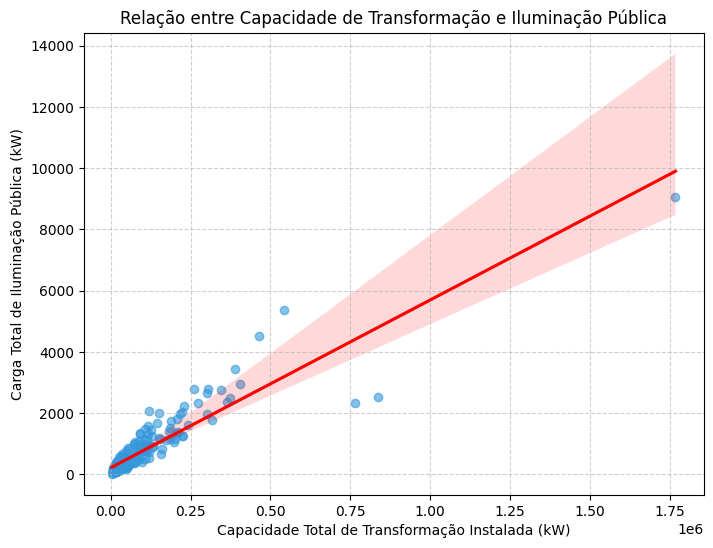

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Limpar eventuais valores nulos nas colunas
df_corr = df_final.dropna(subset=['Cap_PTD', 'P_IP_Total'])

# 2. Extrair as duas variáveis
capacidade = df_corr['Cap_PTD']
iluminacao = df_corr['P_IP_Total']

print("==================================================")
print("TESTE DE CORRELAÇÃO DE PEARSON (Totalidade dos Concelhos)")
print("==================================================")

# 3. Calcular o Coeficiente de Pearson e o p-value
r_pearson, p_value = stats.pearsonr(capacidade, iluminacao)

print(f"Coeficiente de Correlação (r): {r_pearson:.4f}")
print(f"p-value: {p_value:.4e}") # Notação científica, pois o valor deve ser muito próximo de zero

# 4. Conclusão Estatística (nível de significância = 0.05)
if p_value < 0.05:
    print("\n-> Conclusão: Rejeitamos H0.")
    print("Existe uma relação linear ESTATISTICAMENTE SIGNIFICATIVA entre a Capacidade de Transformação e a Iluminação Pública.")
else:
    print("\n-> Conclusão: Não rejeitamos H0.")
    print("NÃO existe uma relação linear estatisticamente significativa.")

# 5. Representação Gráfica
plt.figure(figsize=(8, 6))
sns.regplot(x=capacidade, y=iluminacao, scatter_kws={'alpha':0.6, 'color':'#3498db'}, line_kws={'color':'red'})

plt.title('Relação entre Capacidade de Transformação e Iluminação Pública')
plt.xlabel('Capacidade Total de Transformação Instalada (kW)')
plt.ylabel('Carga Total de Iluminação Pública (kW)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Para avaliar a relação linear entre a capacidade total de transformação instalada e a carga total de iluminação pública nos concelhos, recorreu-se ao coeficiente de correlação de Pearson. O teste revelou um coeficiente de $r = 0.9111$, evidenciando uma correlação linear positiva muito forte. Adicionalmente, o teste de significância resultou num p-value praticamente nulo ($p < 0.001$), rejeitando-se a hipótese nula com elevado grau de confiança estatística. Como ilustrado no gráfico de dispersão, confirma-se que o dimensionamento da infraestrutura de transformação (Cap_PTD) nos municípios portugueses acompanha de forma altamente proporcional e linear as necessidades de carga da iluminação pública.

1. Os pontos muito abaixo da linha vermelha (Por exemplo, aqueles dois pontos perto do 0.75 no eixo do X, mas muito em baixo no eixo do Y):

> O que significam matematicamente: Têm um valor de X (Capacidade) muito alto, mas um valor de Y (Iluminação) muito baixo para o esperado.

> O que significam no mundo real: São concelhos que têm uma infraestrutura elétrica gigante, mas gastam muito pouca energia a iluminar as ruas.

> Porquê? Podem ser concelhos fortemente industriais (como Sines ou Palmela, onde os transformadores gigantes servem fábricas e não candeeiros) ou podem ser concelhos que já substituíram 100% da sua iluminação por LED, reduzindo drasticamente a carga (o eixo do Y) sem precisarem de deitar os transformadores fora (o eixo do X).

2. Os pontos muito acima da linha vermelha
(Há ali um ponto perto do 0.5 no eixo do X que dispara para cima):

> O que significam matematicamente: Têm muito mais Y (Iluminação) do que seria de esperar para o X (Capacidade) que possuem.

> O que significam no mundo real: São concelhos com redes elétricas modestas, mas com um gasto brutal em iluminação pública.

> Porquê? Podem ser concelhos com redes de iluminação totalmente obsoletas e ineficientes (lâmpadas antigas de mercúrio), ou concelhos com muita densidade turística/histórica que exige iluminação noturna excessiva.

### 6. Correlação e Regressão - Modelo Preditivo

Para garantir que o modelo de regressão será robusto, validamos a correlação de Pearson especificamente nos distritos com maior densidade de infraestrutura: Aveiro, Braga, Lisboa e Porto. Uma correlação elevada nestas regiões confirma que a rede elétrica cresce de forma coordenada com a iluminação pública, validando a escolha destas variáveis para o modelo preditivo

In [ ]:
import pandas as pd
import statsmodels.api as sm

print("--- Tabela de Correlação (4 Distritos) ---")

# Aveiro(1), Braga(3), Lisboa(11), Porto(13)
distritos_foco = [1, 3, 11, 13] 
df_corr = df_final[df_final['CodDistrito'].isin(distritos_foco)]

tabela_corr = df_corr[['Cap_PTD', 'P_IP_Total']].corr(method='pearson')
display(tabela_corr)


--- Tabela de Correlação (4 Distritos) ---


,Cap_PTD,P_IP_Total
Cap_PTD,1.000000,0.912912
P_IP_Total,0.912912,1.000000


#### Modelo de Regressão Linear Múltipla

Para identificar os fatores que influenciam o nível de ocupação da rede ($Y$), implementámos um modelo de Mínimos Quadrados Ordinários (OLS). Considerámos como preditores ($X$): a carga total de iluminação pública, a capacidade instalada dos PTDs e o rácio de ineficiência tecnológica.Esta análise permite-nos:
> 1. Quantificar o peso de cada variável no carregamento da rede.
> 2. Validar a significância estatística de cada fator (através dos p-values).
> 3. Obter a base matemática para prever a libertação de potência ao substituir lâmpadas ineficientes por LED.

In [ ]:
print("\n--- Modelo de Regressão Linear Múltipla ---")

# Filtrar para Portugal Continental (Códigos de Distrito de 1 a 18)
colunas_modelo = ['P_IP_Total', 'Cap_PTD', 'Rate_Ineficiencia', 'Util_Media']
df_cont = df_final[(df_final['CodDistrito'] >= 1) & (df_final['CodDistrito'] <= 18)].dropna(subset=colunas_modelo)

# Definir as variáveis X (Pistas) e Y (Alvo)
X = df_cont[['P_IP_Total', 'Cap_PTD', 'Rate_Ineficiencia']]
Y = df_cont['Util_Media']

# Adicionar a constante (Intercepto Beta 0)
X = sm.add_constant(X)

# Criar e treinar o modelo (OLS - Ordinary Least Squares)
modelo_rlm = sm.OLS(Y, X).fit()

# Mostrar os resultados completos do modelo
print(modelo_rlm.summary())


--- Modelo de Regressão Linear Múltipla ---
                            OLS Regression Results                            
Dep. Variable:             Util_Media   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     7.300
Date:                Sat, 28 Mar 2026   Prob (F-statistic):           0.000100
Time:                        21:16:53   Log-Likelihood:                 367.10
No. Observations:                 278   AIC:                            -726.2
Df Residuals:                     274   BIC:                            -711.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

> Através da regressão linear múltipla (OLS) para Portugal Continental, obteve-se um modelo preditivo para a Utilização Média da rede com a seguinte equação: $Y = 0.4989 + 4.594\times 10^{-5} X_1 - 2.7\times 10^{-7} X_2 + 0.0127 X_3$. O modelo apresenta um baixo coeficiente de determinação ($R^2 = 0.074$), indicando que as variáveis selecionadas apenas explicam 7,4% da variância observada, visto omitirem os consumos domésticos e industriais. A análise de significância revela que a Potência de Iluminação e a Capacidade do PTD são variáveis estatisticamente significativas (p-value < 0.001), enquanto a Ineficiência não tem impacto estatístico no modelo (p-value = 0.577). Por fim, o modelo alerta para a presença de multicolinearidade moderada, expectável devido à natureza correlacionada das infraestruturas.

#### Diagnóstico de Resíduos e Validação de Pressupostos (Gauss-Markov)
Para garantir a fiabilidade das inferências do modelo OLS, validamos os três pressupostos fundamentais sobre os resíduos:

> Normalidade: Os erros devem seguir uma distribuição normal para que os testes t e F sejam válidos.

> Independência: Não deve haver correlação entre erros adjacentes (ausência de autocorrelação).

> Homocedasticidade: A variância dos erros deve ser constante. Se a variância mudar com o nível de carga, o modelo é menos preciso em certos intervalos (Heterocedasticidade).

In [ ]:
import scipy.stats as stats
import statsmodels.stats.api as sms

# Extrair os resíduos (erros) do modelo que criamos antes (modelo_rlm)
residuos = modelo_rlm.resid

# 1. Normalidade (Teste de Shapiro-Wilk)
stat_sw, p_sw = stats.shapiro(residuos)
print(f"Normalidade (Shapiro-Wilk): p-value = {p_sw:.4f}")

# 2. Independência (Estatística de Durbin-Watson)
dw_stat = sm.stats.stattools.durbin_watson(residuos)
print(f"Independência (Durbin-Watson): Estatística = {dw_stat:.4f}")

# 3. Homocedasticidade (Teste de Breusch-Pagan)
stat_bp, p_bp, _, _ = sms.het_breuschpagan(residuos, modelo_rlm.model.exog)
print(f"Homocedasticidade (Breusch-Pagan): p-value = {p_bp:.4f}")

Normalidade (Shapiro-Wilk): p-value = 0.0301
Independência (Durbin-Watson): Estatística = 1.4330
Homocedasticidade (Breusch-Pagan): p-value = 0.1710


> A validação dos pressupostos de Gauss-Markov revelou que o modelo apresenta homocedasticidade ($p=0.1710$), garantindo estabilidade na variância dos resíduos. Embora o teste de Shapiro-Wilk aponte para uma ligeira fuga à normalidade ($p=0.0301$), a dimensão da amostra permite assegurar a validade das estimativas. A estatística de Durbin-Watson ($1.433$) sugere uma autonomia aceitável dos resíduos, permitindo avançar para a análise preditiva com segurança.

#### Avaliação de Multicolinearidade (VIF)
Para garantir que as variáveis independentes (Carga IP, Capacidade PTD e Rácio de Ineficiência) fornecem informações independentes ao modelo, calculamos o Factor de Inflação de Variância (VIF). A multicolinearidade excessiva pode inflacionar os erros padrão e tornar os coeficientes $\beta$ pouco fiáveis. Como regra geral, um $VIF > 5$ sugere uma correlação moderada, e um $VIF > 10$ indica uma multicolinearidade severa que exigiria a remoção ou transformação de variáveis.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Criar um DataFrame em branco para apresentar os resultados
vif_data = pd.DataFrame()

# A variável X já tem as tuas 3 variáveis + a constante
vif_data["Variável"] = X.columns

# Calcular o VIF para cada uma das colunas no X
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Mostrar a tabela final, arredondada a 2 casas decimais
display(vif_data.round(2))

,Variável,VIF
0,const,2.18
1,P_IP_Total,8.45
2,Cap_PTD,7.26
3,Rate_Ineficiencia,1.52


#### Validação do Modelo: Previsão para o Distrito de Aveiro (Concelhos 101-109)
Nesta fase, testamos a capacidade preditiva do nosso modelo de Regressão Linear Múltipla num cenário real e localizado. Selecionámos os nove concelhos de Aveiro indicados no enunciado para comparar a Utilização Real vs. Utilização Prevista. O cálculo do 'Erro' (Resíduo) permite-nos avaliar se o modelo está a sobrestimar ou subestimar a carga na rede nestas zonas específicas, fornecendo uma medida da fiabilidade das nossas previsões para o planeamento de infraestruturas VE.

In [ ]:
import pandas as pd
import statsmodels.api as sm

# 1. Definir os códigos dos concelhos pedidos no enunciado
codigos_alvo = [101, 102, 103, 104, 105, 106, 107, 108, 109]
codigo_conc = 'CodDistritoConcelho' 

# 2. Filtrar os dados reais apenas para estes concelhos
df_teste = df_final[df_final[codigo_conc].isin(codigos_alvo)].copy()

# 3. Preparar as "pistas" (Variáveis X) e adicionar a Constante (obrigatório para o modelo prever corretamente)
X_teste = df_teste[['P_IP_Total', 'Cap_PTD', 'Rate_Ineficiencia']]
X_teste = sm.add_constant(X_teste, has_constant='add')

# 4. Usar o modelo para fazer a estimativa matemática (Y Previsto)
y_previsto = modelo_rlm.predict(X_teste)

# 5. Criar uma tabela de comparação lado a lado
tabela_comparacao = pd.DataFrame({
    'Código': df_teste[codigo_conc],
    'Concelho': df_teste['Concelho'], 
    'Y Real': df_teste['Util_Media'],
    'Y Previsto': y_previsto
})

# 6. Calcular a diferença (Erro) entre a realidade e o modelo
tabela_comparacao['Erro'] = tabela_comparacao['Y Real'] - tabela_comparacao['Y Previsto']

# Mostrar os resultados arredondados a 4 casas decimais
display(tabela_comparacao.round(4))

,Código,Concelho,Y Real,Y Previsto,Erro
0,102,Albergaria-a-Velha,0.4699,0.5057,-0.0358
1,103,Anadia,0.5430,0.5155,0.0275
2,104,Arouca,0.5274,0.5170,0.0104
3,105,Aveiro,0.4755,0.4958,-0.0203
4,106,Castelo de Paiva,0.5432,0.5144,0.0288
5,107,Espinho,0.4434,0.5014,-0.0580
6,108,Estarreja,0.5076,0.5074,0.0002
12,109,Santa Maria da Feira,0.5829,0.5372,0.0457
17,101,Águeda,0.4776,0.5156,-0.0380


#### Identificação de Concelhos para Investimento (Análise de Risco)
Para selecionar os concelhos mais viáveis para a instalação de carregadores de 22 kW, adotamos uma estratégia de minimização de risco estatístico. Em vez de usarmos apenas a média prevista ($Y$), utilizamos o Limite Superior do Intervalo de Confiança (95%).
> Lógica: Se um concelho apresenta um Limite Superior baixo, significa que, mesmo na previsão mais pessimista (extremo superior do erro), a utilização da rede continua a ser baixa, garantindo que haverá sempre folga para o carregamento de veículos elétricos sem causar apagões ou sobrecargas.

In [ ]:
print("CONCELHOS MAIS VIÁVEIS (Baseado nos Intervalos de Confiança)")

# 1. Obter as previsões completas com os intervalos de confiança a 95% (alpha=0.05)
previsoes_completas = modelo_rlm.get_prediction(X).summary_frame(alpha=0.05)

# 2. Criar uma tabela
df_viabilidade = pd.DataFrame({
    'Concelho': df_cont['Concelho'],
    'Y_Real': Y,
    'Y_Previsto': previsoes_completas['mean'],
    'Limite_Inf_95%': previsoes_completas['obs_ci_lower'],
    'Limite_Sup_95%': previsoes_completas['obs_ci_upper']
})

# 3. Ordenar pelos concelhos com o Limite Superior MAIS BAIXO
top_viaveis = df_viabilidade.sort_values(by='Limite_Sup_95%', ascending=True).head(5)

display(top_viaveis.round(200))

CONCELHOS MAIS VIÁVEIS (Baseado nos Intervalos de Confiança)


,Concelho,Y_Real,Y_Previsto,Limite_Inf_95%,Limite_Sup_95%
189,Porto,0.421909,0.394000,0.248110,0.539890
194,Vila Nova de Gaia,0.417874,0.400212,0.259220,0.541204
153,Lisboa,0.400514,0.438184,0.279182,0.597185
100,Évora,0.454628,0.488549,0.359833,0.617265
23,Beja,0.446739,0.492760,0.364203,0.621318


Num contexto de engenharia de redes, a tomada de decisão para a alocação de nova carga não deve basear-se apenas na média prevista, mas sim no limite superior do intervalo de confiança (Limite_Sup_95%), que representa o cenário mais conservador de saturação da rede.
> A análise identificou que municípios de grande densidade urbana como o Porto e Vila Nova de Gaia apresentam os limites superiores de previsão mais baixos do país (53,99% e 54,12%, respetivamente). Segue-se Lisboa, com um limite máximo esperado de 59,72%. Nestes concelhos, existe evidência estatística de que a rede possui uma folga de potência superior a 40%, sendo capaz de absorver os picos de carga gerados por infraestruturas de carregamento rápido sem comprometer a estabilidade dos Postos de Transformação. Contudo, dado o baixo poder explicativo geral do modelo ($R^2_{adj} = 6.4\%$), recomenda-se que estas previsões macroscópicas sejam validadas com medições locais antes da instalação física dos equipamentos.